Advitiya Apurv 24EE10029 Afrin Munshi 24EE10030

Remove the comments to get the activation maps

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])
train_dataset = datasets.FashionMNIST('F_MNIST_data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('F_MNIST_data', train=False, download=True, transform=transform)


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.0MB/s]


In [3]:
indices = list(range(len(train_dataset)))
np.random.shuffle(indices)
split = int(np.floor(0.2*len(train_dataset)))
train_ids, valid_ids = indices[split:], indices[:split]
train_sampler = torch.utils.data.SubsetRandomSampler(train_ids)
val_sampler = torch.utils.data.SubsetRandomSampler(valid_ids)

In [4]:
BATCH_SIZE =128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=val_sampler)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,shuffle = False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Length of train data is 48000
Length of test data is 10000
Length of validation data is 12000
torch.Size([1, 28, 28]) torch.Size([128])
Trouser


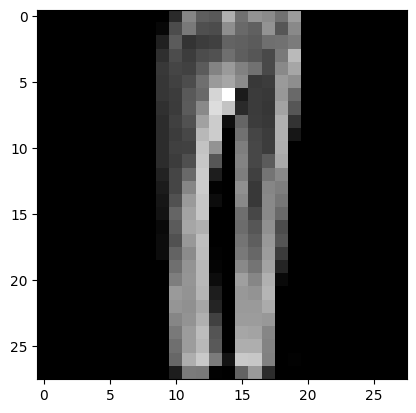

In [5]:
print("Length of train data is " + str(len(train_sampler)))
print("Length of test data is " + str(len(test_dataset)))
print("Length of validation data is " + str(len(val_sampler)))


image, label = next(iter(train_loader))
print(image[0].shape, label.shape)


desc = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]


print(desc[label[0].item()])


plt.imshow(image[0].numpy().squeeze(), cmap='gray')
plt.show()

In [6]:
class BaseModel(nn.Module):
    def __init__(self):
        super(BaseModel, self).__init__()


        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )


        self.block2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )


        self.block3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=2, padding=1),
            nn.ReLU()
        )


        self.flatten = nn.Flatten()


        self.fc1 = nn.Linear(64 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = BaseModel().to(device)
print(model)

BaseModel(
  (block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [7]:
def plot_activation_maps(model, image, device):
    model.eval()
    image = image.to(device).unsqueeze(0)


    with torch.no_grad():
        act1 = model.block1(image)
        act2 = model.block2(act1)
        act3 = model.block3(act2)

    activations = [act1, act2, act3]
    layer_names = ['Block 1 (Conv1)', 'Block 2 (Conv2)', 'Block 3 (Conv3)']

    for i, act in enumerate(activations):

        fig, axes = plt.subplots(1, 8, figsize=(15, 2))
        fig.suptitle(f'Activations for {layer_names[i]}', fontsize=12)

        for j in range(8):

            img = act[0, j].cpu().numpy()
            axes[j].imshow(img, cmap='viridis')
            axes[j].axis('off')
        plt.show()



In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

for epoch in range(epochs):
    running_loss = 0.0
    model.train()

    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)


        loss = criterion(outputs, labels)


        loss.backward()


        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        #if (epoch + 1) % 10 == 0:
          #print(f"Visualizing Activations at Epoch {epoch+1}")
          #plot_activation_maps(model, single_image, device)

    print(f'Finished Epoch {epoch+1}, Average Loss: {running_loss/len(train_loader):.4f}')

print("Training Complete!")

Epoch [1/50], Step [100/375], Loss: 0.5935
Epoch [1/50], Step [200/375], Loss: 0.4826
Epoch [1/50], Step [300/375], Loss: 0.3290
Finished Epoch 1, Average Loss: 0.5565
Epoch [2/50], Step [100/375], Loss: 0.4610
Epoch [2/50], Step [200/375], Loss: 0.2770
Epoch [2/50], Step [300/375], Loss: 0.2385
Finished Epoch 2, Average Loss: 0.3372
Epoch [3/50], Step [100/375], Loss: 0.2890
Epoch [3/50], Step [200/375], Loss: 0.2385
Epoch [3/50], Step [300/375], Loss: 0.1320
Finished Epoch 3, Average Loss: 0.2814
Epoch [4/50], Step [100/375], Loss: 0.2378
Epoch [4/50], Step [200/375], Loss: 0.3241
Epoch [4/50], Step [300/375], Loss: 0.2229
Finished Epoch 4, Average Loss: 0.2517
Epoch [5/50], Step [100/375], Loss: 0.2435
Epoch [5/50], Step [200/375], Loss: 0.2858
Epoch [5/50], Step [300/375], Loss: 0.1978
Finished Epoch 5, Average Loss: 0.2299
Epoch [6/50], Step [100/375], Loss: 0.2754
Epoch [6/50], Step [200/375], Loss: 0.2802
Epoch [6/50], Step [300/375], Loss: 0.1806
Finished Epoch 6, Average Loss:

In [9]:
val_loss = 0.0
model.eval()


with torch.no_grad():
    for i, (images, labels) in enumerate(val_loader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images)


        loss = criterion(outputs, labels)
        val_loss += loss.item()


print(f'Validation Loss: {val_loss/len(val_loader):.4f}')

Validation Loss: 0.6675


In [17]:
def calculate_accuracy(loader, name,model=model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)


            outputs = model(images)


            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'{name} Accuracy: {accuracy:.2f}%')
    return accuracy


train_acc = calculate_accuracy(train_loader, "Training")
val_acc   = calculate_accuracy(val_loader, "Validation")
test_acc  = calculate_accuracy(test_loader, "Test")

Training Accuracy: 99.37%
Validation Accuracy: 91.25%
Test Accuracy: 90.95%


In [11]:
class Exp2Model(nn.Module):
    def __init__(self):
        super(Exp2Model, self).__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 6 * 6, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [21]:
class Exp3Model(nn.Module):
    def __init__(self):
        super(Exp3Model, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3136, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [13]:
class Exp4Model(nn.Module):
    def __init__(self):
        super(Exp4Model, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=2, padding=1),
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [15]:
model2 = Exp2Model().to(device)
print(model2)

Exp2Model(
  (block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2304, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)
epochs = 50

for epoch in range(epochs):
    running_loss = 0.0
    model2.train()

    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)


        optimizer.zero_grad()


        outputs = model2(images)


        loss = criterion(outputs, labels)


        loss.backward()


        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        #if (epoch + 1) % 10 == 0:
          #print(f"Visualizing Activations at Epoch {epoch+1}")
          #plot_activation_maps(model, single_image, device)

    print(f'Finished Epoch {epoch+1}, Average Loss: {running_loss/len(train_loader):.4f}')

print("Training Complete!")

Epoch [1/50], Step [100/375], Loss: 0.5321
Epoch [1/50], Step [200/375], Loss: 0.5918
Epoch [1/50], Step [300/375], Loss: 0.5580
Finished Epoch 1, Average Loss: 0.5413
Epoch [2/50], Step [100/375], Loss: 0.2584
Epoch [2/50], Step [200/375], Loss: 0.3721
Epoch [2/50], Step [300/375], Loss: 0.4268
Finished Epoch 2, Average Loss: 0.3645
Epoch [3/50], Step [100/375], Loss: 0.2570
Epoch [3/50], Step [200/375], Loss: 0.2403
Epoch [3/50], Step [300/375], Loss: 0.3154
Finished Epoch 3, Average Loss: 0.3265
Epoch [4/50], Step [100/375], Loss: 0.3244
Epoch [4/50], Step [200/375], Loss: 0.2585
Epoch [4/50], Step [300/375], Loss: 0.3437
Finished Epoch 4, Average Loss: 0.2938
Epoch [5/50], Step [100/375], Loss: 0.2654
Epoch [5/50], Step [200/375], Loss: 0.2830
Epoch [5/50], Step [300/375], Loss: 0.2524
Finished Epoch 5, Average Loss: 0.2760
Epoch [6/50], Step [100/375], Loss: 0.1563
Epoch [6/50], Step [200/375], Loss: 0.2490
Epoch [6/50], Step [300/375], Loss: 0.3293
Finished Epoch 6, Average Loss:

In [18]:
train_acc = calculate_accuracy(train_loader, "Training",model2)
val_acc   = calculate_accuracy(val_loader, "Validation",model2)
test_acc  = calculate_accuracy(test_loader, "Test",model2)

Training Accuracy: 99.55%
Validation Accuracy: 90.08%
Test Accuracy: 89.84%


In [22]:
model3 = Exp3Model().to(device)
print(model3)

Exp3Model(
  (block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.001)
epochs = 50

for epoch in range(epochs):
    running_loss = 0.0
    model3.train()
    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)


        optimizer.zero_grad()


        outputs = model3(images)


        loss = criterion(outputs, labels)


        loss.backward()


        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        #if (epoch + 1) % 10 == 0:
          #print(f"Visualizing Activations at Epoch {epoch+1}")
          #plot_activation_maps(model, single_image, device)

    print(f'Finished Epoch {epoch+1}, Average Loss: {running_loss/len(train_loader):.4f}')

print("Training Complete!")

Epoch [1/50], Step [100/375], Loss: 0.6060
Epoch [1/50], Step [200/375], Loss: 0.3665
Epoch [1/50], Step [300/375], Loss: 0.5888
Finished Epoch 1, Average Loss: 0.5419
Epoch [2/50], Step [100/375], Loss: 0.4055
Epoch [2/50], Step [200/375], Loss: 0.3089
Epoch [2/50], Step [300/375], Loss: 0.4429
Finished Epoch 2, Average Loss: 0.3320
Epoch [3/50], Step [100/375], Loss: 0.3419
Epoch [3/50], Step [200/375], Loss: 0.2250
Epoch [3/50], Step [300/375], Loss: 0.3518
Finished Epoch 3, Average Loss: 0.2889
Epoch [4/50], Step [100/375], Loss: 0.1863
Epoch [4/50], Step [200/375], Loss: 0.2050
Epoch [4/50], Step [300/375], Loss: 0.2720
Finished Epoch 4, Average Loss: 0.2620
Epoch [5/50], Step [100/375], Loss: 0.2465
Epoch [5/50], Step [200/375], Loss: 0.2046
Epoch [5/50], Step [300/375], Loss: 0.3049
Finished Epoch 5, Average Loss: 0.2384
Epoch [6/50], Step [100/375], Loss: 0.2358
Epoch [6/50], Step [200/375], Loss: 0.2324
Epoch [6/50], Step [300/375], Loss: 0.1901
Finished Epoch 6, Average Loss:

In [24]:
train_acc = calculate_accuracy(train_loader, "Training",model3)
val_acc   = calculate_accuracy(val_loader, "Validation",model3)
test_acc  = calculate_accuracy(test_loader, "Test",model3)

Training Accuracy: 99.52%
Validation Accuracy: 90.86%
Test Accuracy: 90.38%


In [25]:
model4 = Exp4Model().to(device)
print(model4)

Exp4Model(
  (block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model4.parameters(), lr=0.001)
epochs = 50

for epoch in range(epochs):
    running_loss = 0.0
    model4.train()
    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)


        optimizer.zero_grad()


        outputs = model4(images)


        loss = criterion(outputs, labels)


        loss.backward()


        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        #if (epoch + 1) % 10 == 0:
          #print(f"Visualizing Activations at Epoch {epoch+1}")
          #plot_activation_maps(model, single_image, device)

    print(f'Finished Epoch {epoch+1}, Average Loss: {running_loss/len(train_loader):.4f}')

print("Training Complete!")

Epoch [1/50], Step [100/375], Loss: 0.5724
Epoch [1/50], Step [200/375], Loss: 0.5279
Epoch [1/50], Step [300/375], Loss: 0.5529
Finished Epoch 1, Average Loss: 0.6380
Epoch [2/50], Step [100/375], Loss: 0.5301
Epoch [2/50], Step [200/375], Loss: 0.3410
Epoch [2/50], Step [300/375], Loss: 0.3687
Finished Epoch 2, Average Loss: 0.3854
Epoch [3/50], Step [100/375], Loss: 0.3744
Epoch [3/50], Step [200/375], Loss: 0.3405
Epoch [3/50], Step [300/375], Loss: 0.2411
Finished Epoch 3, Average Loss: 0.3304
Epoch [4/50], Step [100/375], Loss: 0.3929
Epoch [4/50], Step [200/375], Loss: 0.3064
Epoch [4/50], Step [300/375], Loss: 0.2690
Finished Epoch 4, Average Loss: 0.2986
Epoch [5/50], Step [100/375], Loss: 0.2260
Epoch [5/50], Step [200/375], Loss: 0.3519
Epoch [5/50], Step [300/375], Loss: 0.3069
Finished Epoch 5, Average Loss: 0.2710
Epoch [6/50], Step [100/375], Loss: 0.3371
Epoch [6/50], Step [200/375], Loss: 0.3718
Epoch [6/50], Step [300/375], Loss: 0.2111
Finished Epoch 6, Average Loss:

In [30]:
train_acc = calculate_accuracy(train_loader, "Training",model4)
val_acc   = calculate_accuracy(val_loader, "Validation",model4)
test_acc  = calculate_accuracy(test_loader, "Test",model4)

Training Accuracy: 99.54%
Validation Accuracy: 92.04%
Test Accuracy: 91.93%


In [35]:
class Exp5Model(nn.Module):
    def __init__(self):
        super(Exp5Model, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.flatten = nn.Flatten()


        self.dropout = nn.Dropout(0.25)


        self.fc1 = nn.Linear(4096, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.flatten(x)


        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x

In [36]:
model5 = Exp5Model().to(device)
print(model5)

Exp5Model(
  (block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model5.parameters(), lr=0.001)
epochs = 50

for epoch in range(epochs):
    running_loss = 0.0
    model5.train()
    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)


        optimizer.zero_grad()


        outputs = model5(images)


        loss = criterion(outputs, labels)


        loss.backward()


        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        #if (epoch + 1) % 10 == 0:
          #print(f"Visualizing Activations at Epoch {epoch+1}")
          #plot_activation_maps(model, single_image, device)

    print(f'Finished Epoch {epoch+1}, Average Loss: {running_loss/len(train_loader):.4f}')

print("Training Complete!")

Epoch [1/50], Step [100/375], Loss: 0.6390
Epoch [1/50], Step [200/375], Loss: 0.5245
Epoch [1/50], Step [300/375], Loss: 0.2273
Finished Epoch 1, Average Loss: 0.4579
Epoch [2/50], Step [100/375], Loss: 0.3920
Epoch [2/50], Step [200/375], Loss: 0.2630
Epoch [2/50], Step [300/375], Loss: 0.2335
Finished Epoch 2, Average Loss: 0.2965
Epoch [3/50], Step [100/375], Loss: 0.2907
Epoch [3/50], Step [200/375], Loss: 0.2685
Epoch [3/50], Step [300/375], Loss: 0.2592
Finished Epoch 3, Average Loss: 0.2544
Epoch [4/50], Step [100/375], Loss: 0.1672
Epoch [4/50], Step [200/375], Loss: 0.2112
Epoch [4/50], Step [300/375], Loss: 0.3186
Finished Epoch 4, Average Loss: 0.2313
Epoch [5/50], Step [100/375], Loss: 0.2701
Epoch [5/50], Step [200/375], Loss: 0.1932
Epoch [5/50], Step [300/375], Loss: 0.2616
Finished Epoch 5, Average Loss: 0.2095
Epoch [6/50], Step [100/375], Loss: 0.2822
Epoch [6/50], Step [200/375], Loss: 0.2237
Epoch [6/50], Step [300/375], Loss: 0.1688
Finished Epoch 6, Average Loss:

In [40]:
train_acc = calculate_accuracy(train_loader, "Training",model5)
val_acc   = calculate_accuracy(val_loader, "Validation",model5)
test_acc  = calculate_accuracy(test_loader, "Test",model5)

Training Accuracy: 99.40%
Validation Accuracy: 92.17%
Test Accuracy: 91.64%


In [38]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [41]:
print(f"Exp 1 Parameters: {count_parameters(model):,}")
print(f"Exp 2 Parameters: {count_parameters(model2):,}")
print(f"Exp 3 Parameters: {count_parameters(model3):,}")
print(f"Exp 4 Parameters: {count_parameters(model4):,}")
print(f"Exp 5 Parameters: {count_parameters(model5):,}")

Exp 1 Parameters: 296,074
Exp 2 Parameters: 149,834
Exp 3 Parameters: 218,186
Exp 4 Parameters: 296,074
Exp 5 Parameters: 296,458
